# RQ1 — Pre-training Quality Analysis

This notebook inspects one run produced by `run_pretraining_quality.py`.

The main quantities are $\epsilon_S(t) = \frac{\|S(W_t)-S^\star\|_F^2}{\|S^\star\|_F^2}$ and the held-out pre-training generalization error $\epsilon_{\mathrm{pre}}(t).$

We inspect them against:
- raw SGD update count `step`;
- \(t/d\);
- \(t/d^2\).

The goal is to decide whether the current pre-training trajectory has converged enough and which saved checkpoints represent meaningfully different levels of pre-training quality before moving on to Task 1.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)


Loaded runs:
d=100  | max step =    400,000 | q = 1.753251e+02 | Q = 1.617636e+02 | Q* = 1.938272e+02 | eps_S = 2.548949e-02 | eps_pre = 7.085402e-03 | max check error = 1.048e-15
d=200  | max step =  1,600,000 | q = 3.592574e+02 | Q = 3.296115e+02 | Q* = 3.998930e+02 | eps_S = 2.748147e-02 | eps_pre = 7.502077e-03 | max check error = 1.180e-15
d=500  | max step = 10,000,000 | q = 9.068323e+02 | Q = 8.339113e+02 | Q* = 1.006328e+03 | eps_S = 2.640734e-02 | eps_pre = 7.141501e-03 | max check error = 8.119e-16


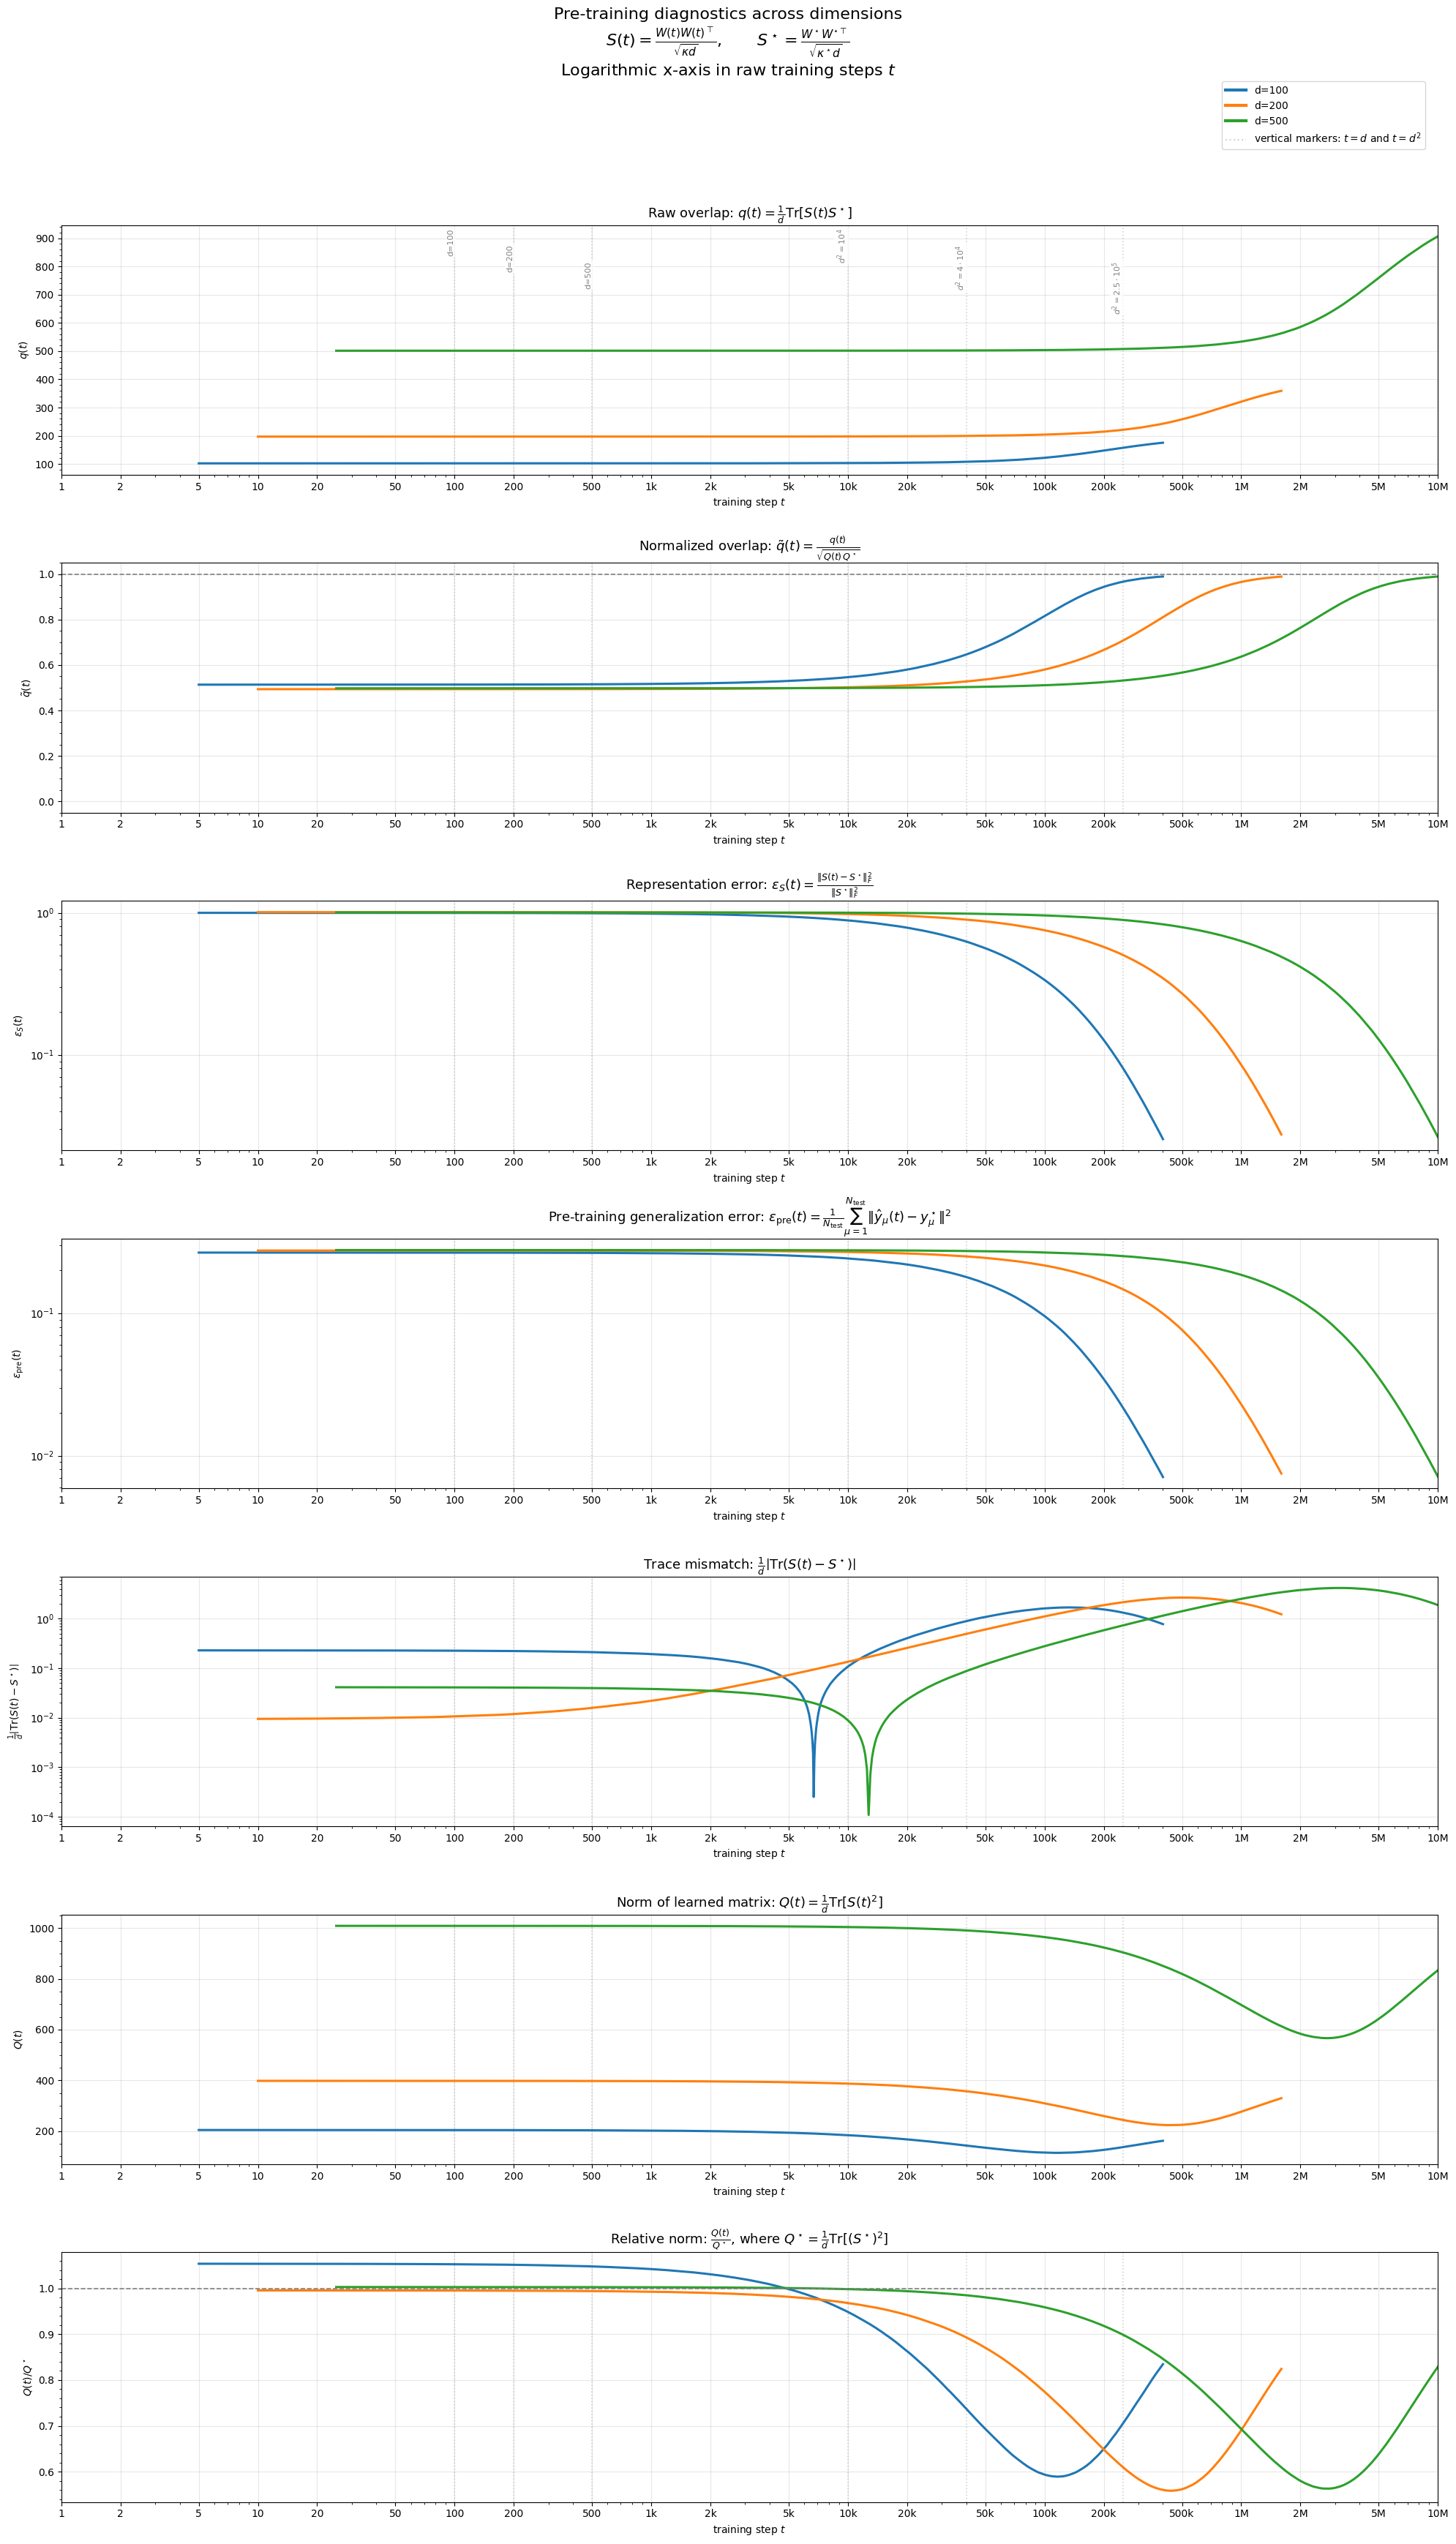

In [7]:
# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

RUNS = {
    "d=100": {"name": "scaling_d100_T5", "d": 100},
    "d=200": {"name": "scaling_d200_T5", "d": 200},
    "d=500": {"name": "scaling_d500_T5", "d": 500},
}

REQUIRED_COLUMNS = [
    "step",
    "representation_error",
    "generalization_error",
    "q",
    "Q",
    "Q_star",
    "normalized_overlap",
    "trace_mismatch",
]

FIGSIZE = (20, 35)
LINEWIDTH = 2.2
XMIN = 1


# ------------------------------------------------------------
# Locate results root
# ------------------------------------------------------------

cwd = Path.cwd()

if (cwd / "results").exists():
    REPO_ROOT = cwd
elif (cwd.parent / "results").exists():
    REPO_ROOT = cwd.parent
else:
    REPO_ROOT = cwd.parent if cwd.name == "notebooks" else cwd

RESULTS_ROOT = REPO_ROOT / "results" / "quality_pretraining"


# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------

def positive_only(x):
    x = np.asarray(x, dtype=float)
    y = x.copy()
    y[y <= 0] = np.nan
    return y


def format_power_label(n):
    """
    Compact formatting for d^2 labels.
    """
    if n == 10_000:
        return r"$10^4$"
    if n == 40_000:
        return r"$4\cdot 10^4$"
    if n == 250_000:
        return r"$2.5\cdot 10^5$"
    if n >= 1_000_000:
        return f"${n/1_000_000:g}\\cdot 10^6$"
    if n >= 1_000:
        k = n / 1_000
        if float(k).is_integer():
            return rf"${int(k)}\cdot 10^3$"
        return rf"${k:g}\cdot 10^3$"
    return str(n)


def add_vertical_scale_lines(ax, d_values):
    """
    Add light gray dotted vertical lines at t=d and t=d^2
    for every run.
    """
    for d in sorted(d_values):
        ax.axvline(
            d,
            color="lightgray",
            linestyle=":",
            linewidth=1.2,
            zorder=0,
        )
        ax.axvline(
            d**2,
            color="lightgray",
            linestyle=":",
            linewidth=1.2,
            zorder=0,
        )


def annotate_vertical_scale_lines(ax, d_values):
    """
    Annotate the vertical scale lines on the top panel only.
    Uses x in data coordinates and y in axes-fraction coordinates.
    """
    d_values = sorted(d_values)

    # Slight staggering to avoid overlap
    y_positions_d = [0.985, 0.92, 0.855]
    y_positions_d2 = [0.985, 0.92, 0.855]

    for i, d in enumerate(d_values):
        ax.text(
            d,
            y_positions_d[i % len(y_positions_d)],
            f"d={d}",
            transform=ax.get_xaxis_transform(),
            rotation=90,
            va="top",
            ha="right",
            fontsize=8,
            color="gray",
            bbox=dict(
                boxstyle="round,pad=0.15",
                facecolor="white",
                edgecolor="none",
                alpha=0.75,
            ),
        )

    for i, d in enumerate(d_values):
        d2 = d**2
        ax.text(
            d2,
            y_positions_d2[i % len(y_positions_d2)],
            rf"$d^2=${format_power_label(d2)}",
            transform=ax.get_xaxis_transform(),
            rotation=90,
            va="top",
            ha="right",
            fontsize=8,
            color="gray",
            bbox=dict(
                boxstyle="round,pad=0.15",
                facecolor="white",
                edgecolor="none",
                alpha=0.75,
            ),
        )


def set_log_x_ticks(ax, xmax):
    candidate_ticks = [
        1, 2, 5,
        10, 20, 50,
        100, 200, 500,
        1_000, 2_000, 5_000,
        10_000, 20_000, 50_000,
        100_000, 200_000, 500_000,
        1_000_000, 2_000_000, 5_000_000,
        10_000_000,
    ]
    ticks = [t for t in candidate_ticks if XMIN <= t <= xmax]
    ax.set_xticks(ticks)

    labels = []
    for t in ticks:
        if t >= 1_000_000:
            labels.append(f"{t/1_000_000:g}M")
        elif t >= 1_000:
            labels.append(f"{t/1_000:g}k")
        else:
            labels.append(str(int(t)))
    ax.set_xticklabels(labels)


def style_axis(ax, ylabel, title, xmax, yscale=None):
    ax.set_xscale("log")
    if yscale is not None:
        ax.set_yscale(yscale)

    ax.set_xlim(XMIN, xmax)
    set_log_x_ticks(ax, xmax)

    ax.set_xlabel(r"training step $t$")
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontsize=13)
    ax.grid(True, alpha=0.3)
    ax.minorticks_on()


# ------------------------------------------------------------
# Load runs
# ------------------------------------------------------------

runs = {}
warnings_list = []

for label, info in RUNS.items():
    run_dir = RESULTS_ROOT / info["name"]
    metrics_path = run_dir / "metrics.csv"

    if not metrics_path.exists():
        warnings_list.append(f"{label}: missing file {metrics_path}")
        continue

    df = pd.read_csv(metrics_path)
    df = (
        df.sort_values("step")
          .drop_duplicates(subset="step", keep="last")
          .reset_index(drop=True)
    )

    missing_cols = [c for c in REQUIRED_COLUMNS if c not in df.columns]
    if missing_cols:
        warnings_list.append(
            f"{label}: missing columns {missing_cols} in {metrics_path}"
        )
        continue

    d = info["d"]

    df["relative_norm"] = df["Q"] / df["Q_star"]

    df["representation_error_from_OP"] = (
        (df["Q"] + df["Q_star"] - 2.0 * df["q"]) / df["Q_star"]
    )
    df["representation_error_check_abs"] = np.abs(
        df["representation_error"] - df["representation_error_from_OP"]
    )

    # remove t=0 for log-x plotting
    df_plot = df[df["step"] > 0].copy()

    runs[label] = {
        "d": d,
        "df": df,
        "df_plot": df_plot,
        "path": metrics_path,
    }

if warnings_list:
    print("Warnings:")
    for w in warnings_list:
        print(" -", w)
    print()

if not runs:
    raise RuntimeError(
        "No valid runs were loaded. "
        "Check that the new metrics.csv files exist and contain the required columns."
    )


# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

print("Loaded runs:")
for label, payload in runs.items():
    df = payload["df"]
    d = payload["d"]
    last = df.iloc[-1]
    print(
        f"{label:6s} | "
        f"max step = {int(last['step']):>10,d} | "
        f"q = {last['q']:.6e} | "
        f"Q = {last['Q']:.6e} | "
        f"Q* = {last['Q_star']:.6e} | "
        f"eps_S = {last['representation_error']:.6e} | "
        f"eps_pre = {last['generalization_error']:.6e} | "
        f"max check error = {df['representation_error_check_abs'].max():.3e}"
    )


# ------------------------------------------------------------
# Figure setup
# ------------------------------------------------------------

fig, axes = plt.subplots(
    7, 1,
    figsize=FIGSIZE,
    sharex=False,
)

default_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
color_map = {}
for i, label in enumerate(runs.keys()):
    color_map[label] = default_colors[i % len(default_colors)]

all_d_values = [payload["d"] for payload in runs.values()]
xmax = max(payload["df_plot"]["step"].max() for payload in runs.values())


# ------------------------------------------------------------
# Plot each run on each panel
# ------------------------------------------------------------

for label, payload in runs.items():
    d = payload["d"]
    df = payload["df_plot"]
    color = color_map[label]

    axes[0].plot(
        df["step"], df["q"],
        lw=LINEWIDTH, color=color, label=label
    )

    axes[1].plot(
        df["step"], df["normalized_overlap"],
        lw=LINEWIDTH, color=color, label=label
    )

    axes[2].plot(
        df["step"], positive_only(df["representation_error"]),
        lw=LINEWIDTH, color=color, label=label
    )

    axes[3].plot(
        df["step"], positive_only(df["generalization_error"]),
        lw=LINEWIDTH, color=color, label=label
    )

    axes[4].plot(
        df["step"], positive_only(df["trace_mismatch"]),
        lw=LINEWIDTH, color=color, label=label
    )

    axes[5].plot(
        df["step"], df["Q"],
        lw=LINEWIDTH, color=color, label=label
    )

    axes[6].plot(
        df["step"], df["relative_norm"],
        lw=LINEWIDTH, color=color, label=label
    )


# ------------------------------------------------------------
# Add vertical dotted lines everywhere
# ------------------------------------------------------------

for ax in axes:
    add_vertical_scale_lines(ax, all_d_values)

# Add labels only on the top panel
annotate_vertical_scale_lines(axes[0], all_d_values)


# ------------------------------------------------------------
# Reference horizontal lines
# ------------------------------------------------------------

axes[1].axhline(
    1.0, color="gray", linestyle="--", linewidth=1.2
)

axes[6].axhline(
    1.0, color="gray", linestyle="--", linewidth=1.2
)


# ------------------------------------------------------------
# Axis styling
# ------------------------------------------------------------

style_axis(
    axes[0],
    ylabel=r"$q(t)$",
    title=(
        r"Raw overlap: "
        r"$q(t)=\frac{1}{d}\operatorname{Tr}\!\left[S(t)S^\star\right]$"
    ),
    xmax=xmax,
)

style_axis(
    axes[1],
    ylabel=r"$\tilde q(t)$",
    title=(
        r"Normalized overlap: "
        r"$\tilde q(t)=\frac{q(t)}{\sqrt{Q(t)\,Q^\star}}$"
    ),
    xmax=xmax,
)
axes[1].set_ylim(-0.05, 1.05)

style_axis(
    axes[2],
    ylabel=r"$\epsilon_S(t)$",
    title=(
        r"Representation error: "
        r"$\epsilon_S(t)=\frac{\|S(t)-S^\star\|_F^2}{\|S^\star\|_F^2}$"
    ),
    xmax=xmax,
    yscale="log",
)

style_axis(
    axes[3],
    ylabel=r"$\epsilon_{\mathrm{pre}}(t)$",
    title=(
        r"Pre-training generalization error: "
        r"$\epsilon_{\mathrm{pre}}(t)=\frac{1}{N_{\mathrm{test}}}"
        r"\sum_{\mu=1}^{N_{\mathrm{test}}}"
        r"\|\hat y_\mu(t)-y_\mu^\star\|^2$"
    ),
    xmax=xmax,
    yscale="log",
)

style_axis(
    axes[4],
    ylabel=r"$\frac{1}{d}\left|\operatorname{Tr}(S(t)-S^\star)\right|$",
    title=(
        r"Trace mismatch: "
        r"$\frac{1}{d}\left|\operatorname{Tr}(S(t)-S^\star)\right|$"
    ),
    xmax=xmax,
    yscale="log",
)

style_axis(
    axes[5],
    ylabel=r"$Q(t)$",
    title=(
        r"Norm of learned matrix: "
        r"$Q(t)=\frac{1}{d}\operatorname{Tr}\!\left[S(t)^2\right]$"
    ),
    xmax=xmax,
)

style_axis(
    axes[6],
    ylabel=r"$Q(t)/Q^\star$",
    title=(
        r"Relative norm: "
        r"$\frac{Q(t)}{Q^\star}$"
        r", where "
        r"$Q^\star=\frac{1}{d}\operatorname{Tr}\!\left[(S^\star)^2\right]$"
    ),
    xmax=xmax,
)


# ------------------------------------------------------------
# Legends
# ------------------------------------------------------------

run_handles = [
    Line2D([0], [0], color=color_map[label], lw=3, label=label)
    for label in runs.keys()
]

scale_handles = [
    Line2D([0], [0], color="lightgray", lw=1.5, ls=":", label=r"vertical markers: $t=d$ and $t=d^2$"),
]

# Put legend well above the plots, but below the main title
fig.legend(
    handles=run_handles + scale_handles,
    loc="upper right",
    bbox_to_anchor=(0.98, 0.965),
    ncol=1,
    frameon=True,
)


# ------------------------------------------------------------
# Global title
# ------------------------------------------------------------

fig.suptitle(
    "Pre-training diagnostics across dimensions\n"
    r"$S(t)=\frac{W(t)W(t)^\top}{\sqrt{\kappa d}},\qquad"
    r"S^\star=\frac{W^\star W^{\star\top}}{\sqrt{\kappa^\star d}}$"
    "\n"
    "Logarithmic x-axis in raw training steps "
    r"$t$",
    fontsize=16,
    y=0.992,
)

plt.tight_layout(rect=[0, 0, 1, 0.952])
plt.show()

Loaded runs:
d=100  | step=   400,000 | t/d²=40.000 | eps_S=2.548949e-02 | eps_pre=7.085402e-03 | q=1.753251e+02 | Q/Q*=0.834576
d=200  | step= 1,600,000 | t/d²=40.000 | eps_S=2.748147e-02 | eps_pre=7.502077e-03 | q=3.592574e+02 | Q/Q*=0.824249
d=500  | step=10,000,000 | t/d²=40.000 | eps_S=2.640734e-02 | eps_pre=7.141501e-03 | q=9.068323e+02 | Q/Q*=0.828668


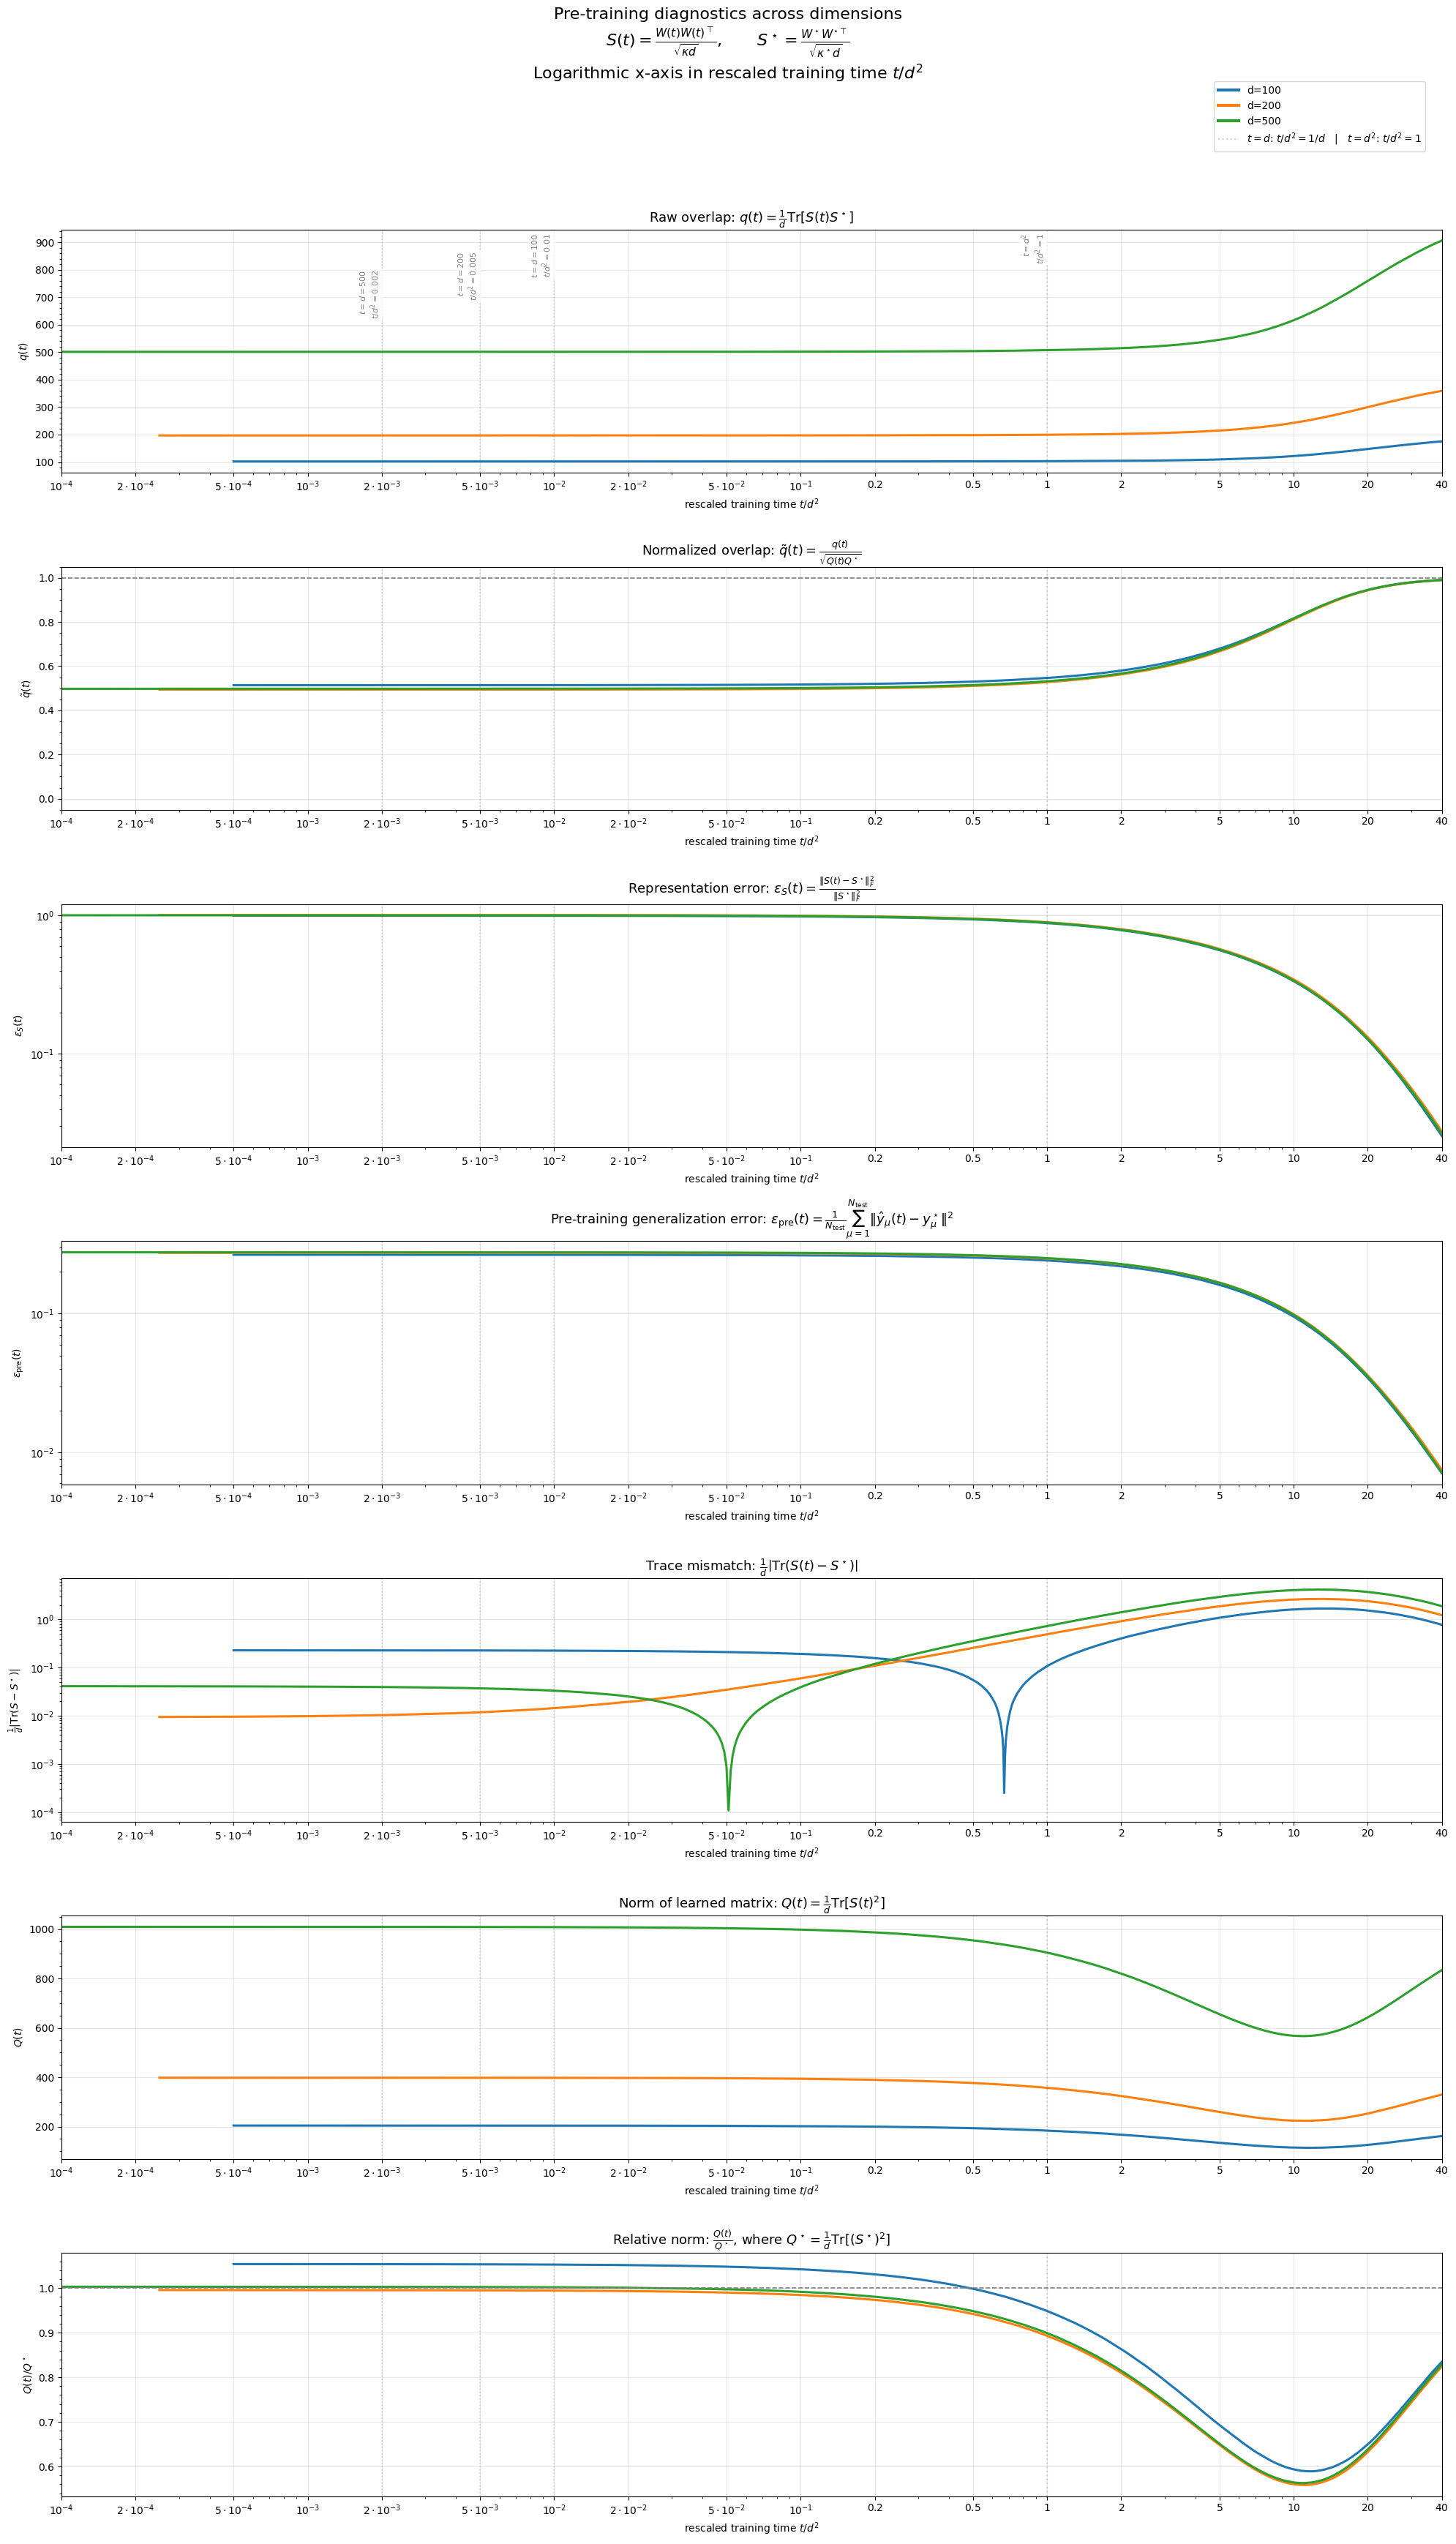

In [8]:
RUNS = {
    "d=100": {"name": "scaling_d100_T5", "d": 100},
    "d=200": {"name": "scaling_d200_T5", "d": 200},
    "d=500": {"name": "scaling_d500_T5", "d": 500},
}

REQUIRED_COLUMNS = [
    "step",
    "representation_error",
    "generalization_error",
    "q",
    "Q",
    "Q_star",
    "normalized_overlap",
    "trace_mismatch",
]

FIGSIZE = (20, 35)
LINEWIDTH = 2.2

# Full alpha range
XMIN = 1e-4
XMAX = 40.0


# ------------------------------------------------------------
# Locate results root
# ------------------------------------------------------------

cwd = Path.cwd()

if (cwd / "results").exists():
    REPO_ROOT = cwd
elif (cwd.parent / "results").exists():
    REPO_ROOT = cwd.parent
else:
    REPO_ROOT = cwd.parent if cwd.name == "notebooks" else cwd

RESULTS_ROOT = REPO_ROOT / "results" / "quality_pretraining"


# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------

def positive_only(x):
    x = np.asarray(x, dtype=float)
    y = x.copy()
    y[y <= 0] = np.nan
    return y


def add_vertical_scale_lines_alpha(ax, d_values):
    """
    On alpha = t/d^2 scale:
        t=d   -> alpha=1/d
        t=d^2 -> alpha=1
    """

    for d in sorted(d_values):
        ax.axvline(
            1.0 / d,
            color="lightgray",
            linestyle=":",
            linewidth=1.2,
            zorder=0,
        )

    # t=d^2 is alpha=1 for every d
    ax.axvline(
        1.0,
        color="lightgray",
        linestyle=":",
        linewidth=1.5,
        zorder=0,
    )


def annotate_vertical_scale_lines_alpha(ax, d_values):
    """
    Label the t=d positions and common t=d^2 position
    on the top panel only.
    """

    d_values = sorted(d_values)

    # Label alpha = 1/d
    y_positions = [0.985, 0.91, 0.835]

    for i, d in enumerate(d_values):
        alpha_d = 1.0 / d

        ax.text(
            alpha_d,
            y_positions[i],
            rf"$t=d={d}$" + "\n" + rf"$t/d^2={alpha_d:g}$",
            transform=ax.get_xaxis_transform(),
            rotation=90,
            va="top",
            ha="right",
            fontsize=8,
            color="gray",
            bbox=dict(
                boxstyle="round,pad=0.15",
                facecolor="white",
                edgecolor="none",
                alpha=0.75,
            ),
        )

    # Common d^2 location
    ax.text(
        1.0,
        0.985,
        r"$t=d^2$" + "\n" + r"$t/d^2=1$",
        transform=ax.get_xaxis_transform(),
        rotation=90,
        va="top",
        ha="right",
        fontsize=8,
        color="gray",
        bbox=dict(
            boxstyle="round,pad=0.15",
            facecolor="white",
            edgecolor="none",
            alpha=0.75,
        ),
    )


def set_alpha_ticks(ax):
    ticks = [
        1e-4,
        2e-4,
        5e-4,
        1e-3,
        2e-3,
        5e-3,
        1e-2,
        2e-2,
        5e-2,
        1e-1,
        2e-1,
        5e-1,
        1,
        2,
        5,
        10,
        20,
        40,
    ]

    ticks = [x for x in ticks if XMIN <= x <= XMAX]

    ax.set_xticks(ticks)

    labels = [
        r"$10^{-4}$",
        r"$2\cdot10^{-4}$",
        r"$5\cdot10^{-4}$",
        r"$10^{-3}$",
        r"$2\cdot10^{-3}$",
        r"$5\cdot10^{-3}$",
        r"$10^{-2}$",
        r"$2\cdot10^{-2}$",
        r"$5\cdot10^{-2}$",
        r"$10^{-1}$",
        r"$0.2$",
        r"$0.5$",
        r"$1$",
        r"$2$",
        r"$5$",
        r"$10$",
        r"$20$",
        r"$40$",
    ]

    ax.set_xticklabels(labels)


def style_axis(
    ax,
    ylabel,
    title,
    yscale=None,
):
    ax.set_xscale("log")

    if yscale is not None:
        ax.set_yscale(yscale)

    ax.set_xlim(XMIN, XMAX)
    set_alpha_ticks(ax)

    ax.set_xlabel(r"rescaled training time $t/d^2$")
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontsize=13)

    ax.grid(True, alpha=0.3)
    ax.minorticks_on()


# ------------------------------------------------------------
# Load runs
# ------------------------------------------------------------

runs = {}
warnings_list = []

for label, info in RUNS.items():
    run_dir = RESULTS_ROOT / info["name"]
    metrics_path = run_dir / "metrics.csv"

    if not metrics_path.exists():
        warnings_list.append(
            f"{label}: missing file {metrics_path}"
        )
        continue

    df = pd.read_csv(metrics_path)

    df = (
        df.sort_values("step")
          .drop_duplicates(
              subset="step",
              keep="last",
          )
          .reset_index(drop=True)
    )

    missing_cols = [
        c for c in REQUIRED_COLUMNS
        if c not in df.columns
    ]

    if missing_cols:
        warnings_list.append(
            f"{label}: missing columns {missing_cols}"
        )
        continue

    d = info["d"]

    # --------------------------------------------------------
    # Derived quantities
    # --------------------------------------------------------

    df["step_over_d2"] = (
        df["step"] / (d ** 2)
    )

    df["relative_norm"] = (
        df["Q"] / df["Q_star"]
    )

    # Sanity check
    df["representation_error_from_OP"] = (
        (
            df["Q"]
            + df["Q_star"]
            - 2.0 * df["q"]
        )
        / df["Q_star"]
    )

    df["representation_error_check_abs"] = (
        np.abs(
            df["representation_error"]
            - df["representation_error_from_OP"]
        )
    )

    # Exclude t=0 because x-axis is logarithmic
    df_plot = (
        df[df["step_over_d2"] > 0]
        .copy()
    )

    runs[label] = {
        "d": d,
        "df": df,
        "df_plot": df_plot,
    }


if warnings_list:
    print("Warnings:")
    for w in warnings_list:
        print(" -", w)
    print()

if not runs:
    raise RuntimeError(
        "No valid runs were loaded."
    )


# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

print("Loaded runs:")

for label, payload in runs.items():
    df = payload["df"]
    d = payload["d"]
    last = df.iloc[-1]

    print(
        f"{label:6s} | "
        f"step={int(last['step']):>10,d} | "
        f"t/d²={last['step_over_d2']:.3f} | "
        f"eps_S={last['representation_error']:.6e} | "
        f"eps_pre={last['generalization_error']:.6e} | "
        f"q={last['q']:.6e} | "
        f"Q/Q*={last['relative_norm']:.6f}"
    )


# ------------------------------------------------------------
# Figure setup
# ------------------------------------------------------------

fig, axes = plt.subplots(
    7,
    1,
    figsize=FIGSIZE,
    sharex=False,
)

default_colors = (
    plt.rcParams["axes.prop_cycle"]
    .by_key()["color"]
)

color_map = {}

for i, label in enumerate(runs.keys()):
    color_map[label] = (
        default_colors[
            i % len(default_colors)
        ]
    )

all_d_values = [
    payload["d"]
    for payload in runs.values()
]


# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

for label, payload in runs.items():

    df = payload["df_plot"]
    color = color_map[label]

    x = df["step_over_d2"]

    # 1. Raw overlap
    axes[0].plot(
        x,
        df["q"],
        lw=LINEWIDTH,
        color=color,
        label=label,
    )

    # 2. Normalized overlap
    axes[1].plot(
        x,
        df["normalized_overlap"],
        lw=LINEWIDTH,
        color=color,
    )

    # 3. Representation error
    axes[2].plot(
        x,
        positive_only(
            df["representation_error"]
        ),
        lw=LINEWIDTH,
        color=color,
    )

    # 4. Generalization error
    axes[3].plot(
        x,
        positive_only(
            df["generalization_error"]
        ),
        lw=LINEWIDTH,
        color=color,
    )

    # 5. Trace mismatch
    axes[4].plot(
        x,
        positive_only(
            df["trace_mismatch"]
        ),
        lw=LINEWIDTH,
        color=color,
    )

    # 6. Raw Q
    axes[5].plot(
        x,
        df["Q"],
        lw=LINEWIDTH,
        color=color,
    )

    # 7. Relative Q
    axes[6].plot(
        x,
        df["relative_norm"],
        lw=LINEWIDTH,
        color=color,
    )


# ------------------------------------------------------------
# Vertical reference lines
# ------------------------------------------------------------

for ax in axes:
    add_vertical_scale_lines_alpha(
        ax,
        all_d_values,
    )

annotate_vertical_scale_lines_alpha(
    axes[0],
    all_d_values,
)


# ------------------------------------------------------------
# Horizontal reference lines
# ------------------------------------------------------------

axes[1].axhline(
    1.0,
    color="gray",
    linestyle="--",
    linewidth=1.2,
)

axes[6].axhline(
    1.0,
    color="gray",
    linestyle="--",
    linewidth=1.2,
)


# ------------------------------------------------------------
# Styling
# ------------------------------------------------------------

style_axis(
    axes[0],
    ylabel=r"$q(t)$",
    title=(
        r"Raw overlap: "
        r"$q(t)=\frac{1}{d}"
        r"\operatorname{Tr}[S(t)S^\star]$"
    ),
)

style_axis(
    axes[1],
    ylabel=r"$\tilde q(t)$",
    title=(
        r"Normalized overlap: "
        r"$\tilde q(t)="
        r"\frac{q(t)}{\sqrt{Q(t)Q^\star}}$"
    ),
)

axes[1].set_ylim(
    -0.05,
    1.05,
)

style_axis(
    axes[2],
    ylabel=r"$\epsilon_S(t)$",
    title=(
        r"Representation error: "
        r"$\epsilon_S(t)="
        r"\frac{\|S(t)-S^\star\|_F^2}"
        r"{\|S^\star\|_F^2}$"
    ),
    yscale="log",
)

style_axis(
    axes[3],
    ylabel=r"$\epsilon_{\mathrm{pre}}(t)$",
    title=(
        r"Pre-training generalization error: "
        r"$\epsilon_{\mathrm{pre}}(t)="
        r"\frac{1}{N_{\mathrm{test}}}"
        r"\sum_{\mu=1}^{N_{\mathrm{test}}}"
        r"\|\hat y_\mu(t)-y_\mu^\star\|^2$"
    ),
    yscale="log",
)

style_axis(
    axes[4],
    ylabel=(
        r"$\frac{1}{d}"
        r"|\operatorname{Tr}(S-S^\star)|$"
    ),
    title=(
        r"Trace mismatch: "
        r"$\frac{1}{d}"
        r"\left|\operatorname{Tr}"
        r"(S(t)-S^\star)\right|$"
    ),
    yscale="log",
)

style_axis(
    axes[5],
    ylabel=r"$Q(t)$",
    title=(
        r"Norm of learned matrix: "
        r"$Q(t)=\frac{1}{d}"
        r"\operatorname{Tr}[S(t)^2]$"
    ),
)

style_axis(
    axes[6],
    ylabel=r"$Q(t)/Q^\star$",
    title=(
        r"Relative norm: "
        r"$\frac{Q(t)}{Q^\star}$"
        r", where "
        r"$Q^\star=\frac{1}{d}"
        r"\operatorname{Tr}[(S^\star)^2]$"
    ),
)


# ------------------------------------------------------------
# Legend
# ------------------------------------------------------------

run_handles = [
    Line2D(
        [0],
        [0],
        color=color_map[label],
        lw=3,
        label=label,
    )
    for label in runs.keys()
]

scale_handles = [
    Line2D(
        [0],
        [0],
        color="lightgray",
        lw=1.5,
        ls=":",
        label=(
            r"$t=d$: $t/d^2=1/d$"
            r"   |   "
            r"$t=d^2$: $t/d^2=1$"
        ),
    ),
]

fig.legend(
    handles=run_handles + scale_handles,
    loc="upper right",
    bbox_to_anchor=(0.98, 0.965),
    ncol=1,
    frameon=True,
)


# ------------------------------------------------------------
# Global title
# ------------------------------------------------------------

fig.suptitle(
    "Pre-training diagnostics across dimensions\n"
    r"$S(t)=\frac{W(t)W(t)^\top}{\sqrt{\kappa d}},"
    r"\qquad"
    r"S^\star="
    r"\frac{W^\star W^{\star\top}}"
    r"{\sqrt{\kappa^\star d}}$"
    "\n"
    r"Logarithmic x-axis in rescaled training time $t/d^2$",
    fontsize=16,
    y=0.992,
)

plt.tight_layout(
    rect=[0, 0, 1, 0.952]
)

plt.show()

## Step 2: finetuning w with task 1

### d = 100

,pretraining_step,finetune_step,finetune_step_over_d,representation_error,pretraining_error,task1_error,overlap_w1,w_norm
91,0,910,9.1,0.999314,0.265647,0.338116,-0.109687,0.010112
92,0,920,9.2,0.999314,0.265647,0.338116,-0.109832,0.010112
93,0,930,9.3,0.999314,0.265647,0.338116,-0.109930,0.010114
94,0,940,9.4,0.999314,0.265647,0.338116,-0.110253,0.010118
95,0,950,9.5,0.999314,0.265647,0.338116,-0.110877,0.010115
96,0,960,9.6,0.999314,0.265647,0.338116,-0.111194,0.010117
97,0,970,9.7,0.999314,0.265647,0.338116,-0.112200,0.010124
98,0,980,9.8,0.999314,0.265647,0.338116,-0.112403,0.010128
99,0,990,9.9,0.999314,0.265647,0.338116,-0.112450,0.010128
100,0,1000,10.0,0.999314,0.265647,0.338116,-0.112130,0.010129


pretraining checkpoint : 0
finetuning step        : 1,000
t/d                    : 10.000
Task-1 error           : 3.381160e-01
Pretraining error      : 2.656469e-01
Overlap with w1*       : -0.112130
||w||                  : 0.010129


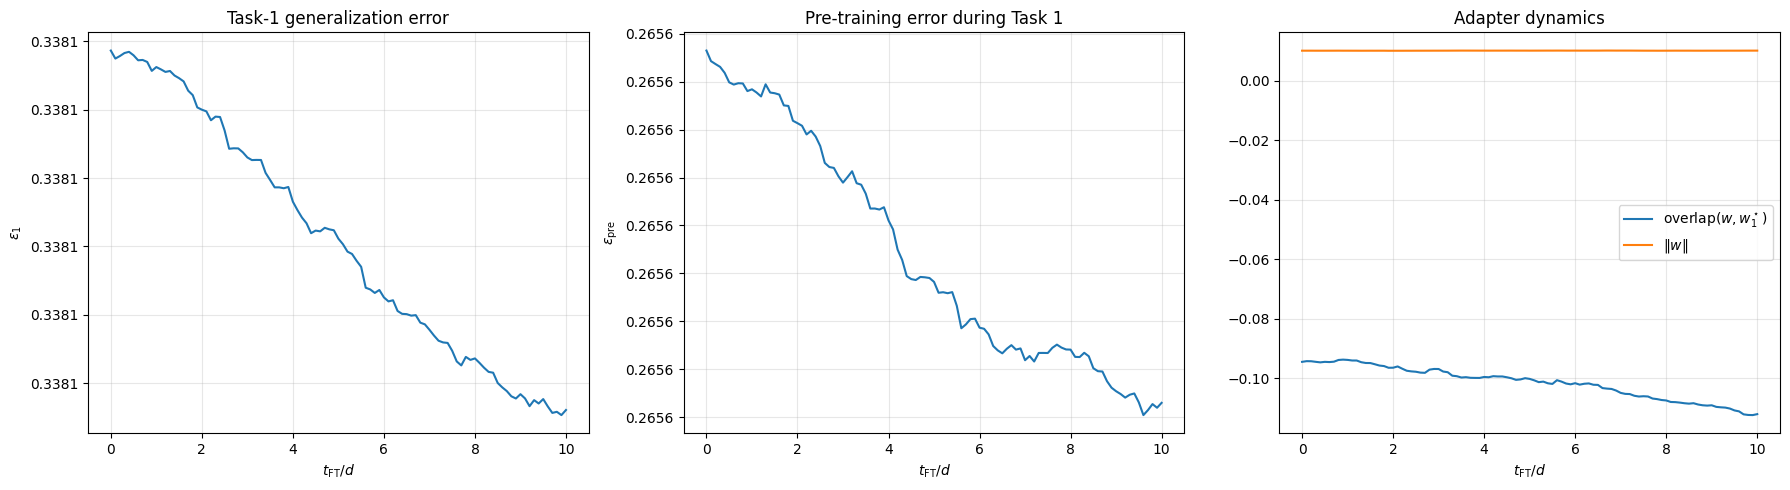

In [53]:

RUN_NAME = "scaling_d100_T5"
PRETRAIN_STEP = 0

RESULTS_ROOT = (
    REPO_ROOT
    / "results"
    / "task1_finetuning"
)

RUN_DIR = RESULTS_ROOT / RUN_NAME

METRICS_PATH = (
    RUN_DIR
    / f"step_{PRETRAIN_STEP}_task1_metrics.csv"
)


# ============================================================
# Load current metrics
# ============================================================

if not METRICS_PATH.exists():
    raise FileNotFoundError(
        f"No metrics found yet:\n{METRICS_PATH}"
    )

df = pd.read_csv(METRICS_PATH)

df = (
    df
    .sort_values("finetune_step")
    .drop_duplicates(
        subset="finetune_step",
        keep="last",
    )
    .reset_index(drop=True)
)

display(df.tail(10))


# ============================================================
# Current status
# ============================================================

last = df.iloc[-1]

print(
    f"pretraining checkpoint : {PRETRAIN_STEP:,}"
)
print(
    f"finetuning step        : "
    f"{int(last['finetune_step']):,}"
)
print(
    f"t/d                    : "
    f"{last['finetune_step_over_d']:.3f}"
)
print(
    f"Task-1 error           : "
    f"{last['task1_error']:.6e}"
)
print(
    f"Pretraining error      : "
    f"{last['pretraining_error']:.6e}"
)
print(
    f"Overlap with w1*       : "
    f"{last['overlap_w1']:.6f}"
)
print(
    f"||w||                  : "
    f"{last['w_norm']:.6f}"
)


# ============================================================
# Plot
# ============================================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5),
)


# ------------------------------------------------------------
# Task-1 generalization error
# ------------------------------------------------------------

axes[0].plot(
    df["finetune_step_over_d"],
    df["task1_error"],
)

axes[0].set_xlabel(r"$t_{\mathrm{FT}}/d$")
axes[0].set_ylabel(
    r"$\epsilon_1$"
)
axes[0].set_title(
    "Task-1 generalization error"
)
axes[0].grid(True, alpha=0.3)


# ------------------------------------------------------------
# Pretraining error during fine-tuning
# ------------------------------------------------------------

axes[1].plot(
    df["finetune_step_over_d"],
    df["pretraining_error"],
)

axes[1].set_xlabel(r"$t_{\mathrm{FT}}/d$")
axes[1].set_ylabel(
    r"$\epsilon_{\mathrm{pre}}$"
)
axes[1].set_title(
    "Pre-training error during Task 1"
)
axes[1].grid(True, alpha=0.3)


# ------------------------------------------------------------
# Adapter alignment
# ------------------------------------------------------------

axes[2].plot(
    df["finetune_step_over_d"],
    df["overlap_w1"],
    label=r"$\mathrm{overlap}(w,w_1^\star)$",
)

axes[2].plot(
    df["finetune_step_over_d"],
    df["w_norm"],
    label=r"$\|w\|$",
)

axes[2].set_xlabel(r"$t_{\mathrm{FT}}/d$")
axes[2].set_title(
    "Adapter dynamics"
)
axes[2].grid(True, alpha=0.3)
axes[2].legend()

for ax in axes[:2]:
    ax.ticklabel_format(
        axis="y",
        style="plain",
        useOffset=False,
    )

from matplotlib.ticker import FormatStrFormatter

axes[0].yaxis.set_major_formatter(
    FormatStrFormatter("%.4f")
)

axes[1].yaxis.set_major_formatter(
    FormatStrFormatter("%.4f")
)

plt.tight_layout()
plt.show()

,pretraining_step,finetune_step,finetune_step_over_d,representation_error,pretraining_error,task1_error,overlap_w1,w_norm
91,50000,910,9.1,0.562478,0.161232,0.239376,-0.112299,0.010118
92,50000,920,9.2,0.562478,0.161232,0.239376,-0.112469,0.010117
93,50000,930,9.3,0.562478,0.161232,0.239376,-0.112633,0.010118
94,50000,940,9.4,0.562478,0.161232,0.239376,-0.113017,0.010122
95,50000,950,9.5,0.562478,0.161232,0.239376,-0.113870,0.010121
96,50000,960,9.6,0.562478,0.161232,0.239376,-0.114262,0.010122
97,50000,970,9.7,0.562478,0.161232,0.239376,-0.115091,0.010127
98,50000,980,9.8,0.562478,0.161232,0.239376,-0.115338,0.010132
99,50000,990,9.9,0.562478,0.161232,0.239376,-0.115259,0.010131
100,50000,1000,10.0,0.562478,0.161232,0.239376,-0.114977,0.010131


pretraining checkpoint : 50,000
finetuning step        : 1,000
t/d                    : 10.000
Task-1 error           : 2.393762e-01
Pretraining error      : 1.612316e-01
Overlap with w1*       : -0.114977
||w||                  : 0.010131


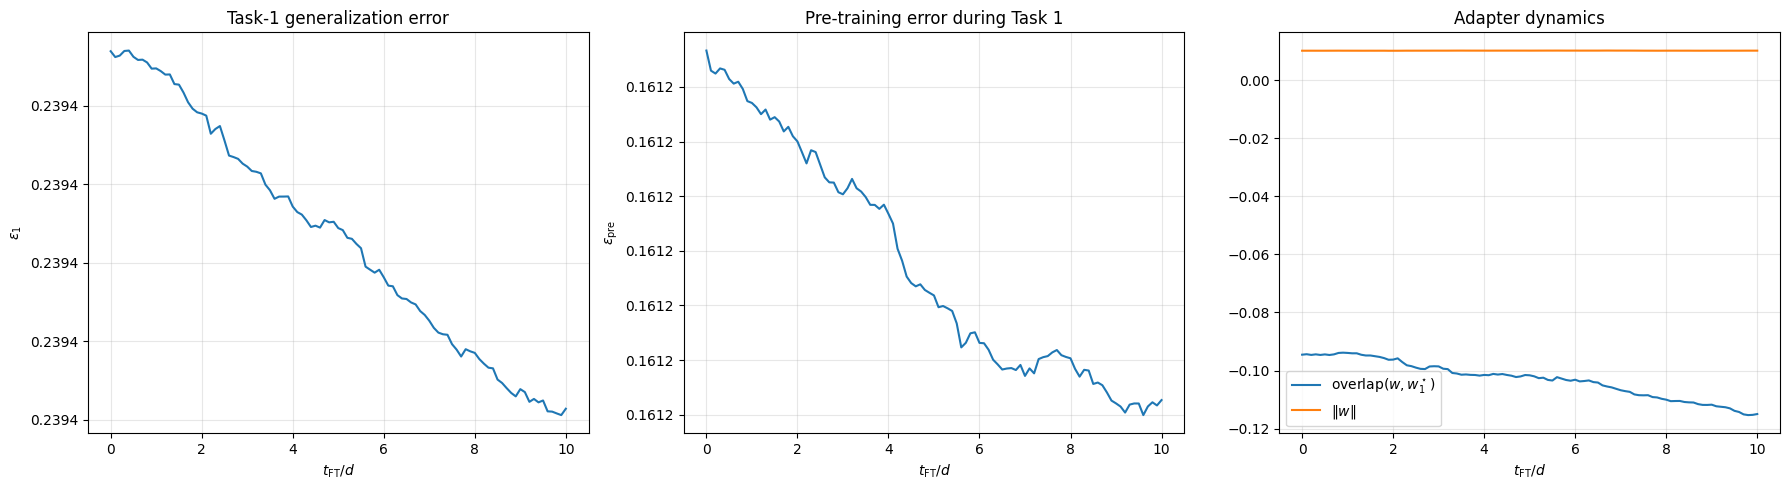

In [54]:
RUN_NAME = "scaling_d100_T5"
PRETRAIN_STEP = 50000

RESULTS_ROOT = (
    REPO_ROOT
    / "results"
    / "task1_finetuning"
)

RUN_DIR = RESULTS_ROOT / RUN_NAME

METRICS_PATH = (
    RUN_DIR
    / f"step_{PRETRAIN_STEP}_task1_metrics.csv"
)


# ============================================================
# Load current metrics
# ============================================================

if not METRICS_PATH.exists():
    raise FileNotFoundError(
        f"No metrics found yet:\n{METRICS_PATH}"
    )

df = pd.read_csv(METRICS_PATH)

df = (
    df
    .sort_values("finetune_step")
    .drop_duplicates(
        subset="finetune_step",
        keep="last",
    )
    .reset_index(drop=True)
)

display(df.tail(10))


# ============================================================
# Current status
# ============================================================

last = df.iloc[-1]

print(
    f"pretraining checkpoint : {PRETRAIN_STEP:,}"
)
print(
    f"finetuning step        : "
    f"{int(last['finetune_step']):,}"
)
print(
    f"t/d                    : "
    f"{last['finetune_step_over_d']:.3f}"
)
print(
    f"Task-1 error           : "
    f"{last['task1_error']:.6e}"
)
print(
    f"Pretraining error      : "
    f"{last['pretraining_error']:.6e}"
)
print(
    f"Overlap with w1*       : "
    f"{last['overlap_w1']:.6f}"
)
print(
    f"||w||                  : "
    f"{last['w_norm']:.6f}"
)


# ============================================================
# Plot
# ============================================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5),
)


# ------------------------------------------------------------
# Task-1 generalization error
# ------------------------------------------------------------

axes[0].plot(
    df["finetune_step_over_d"],
    df["task1_error"],
)

axes[0].set_xlabel(r"$t_{\mathrm{FT}}/d$")
axes[0].set_ylabel(
    r"$\epsilon_1$"
)
axes[0].set_title(
    "Task-1 generalization error"
)
axes[0].grid(True, alpha=0.3)


# ------------------------------------------------------------
# Pretraining error during fine-tuning
# ------------------------------------------------------------

axes[1].plot(
    df["finetune_step_over_d"],
    df["pretraining_error"],
)

axes[1].set_xlabel(r"$t_{\mathrm{FT}}/d$")
axes[1].set_ylabel(
    r"$\epsilon_{\mathrm{pre}}$"
)
axes[1].set_title(
    "Pre-training error during Task 1"
)
axes[1].grid(True, alpha=0.3)


# ------------------------------------------------------------
# Adapter alignment
# ------------------------------------------------------------

axes[2].plot(
    df["finetune_step_over_d"],
    df["overlap_w1"],
    label=r"$\mathrm{overlap}(w,w_1^\star)$",
)

axes[2].plot(
    df["finetune_step_over_d"],
    df["w_norm"],
    label=r"$\|w\|$",
)

axes[2].set_xlabel(r"$t_{\mathrm{FT}}/d$")
axes[2].set_title(
    "Adapter dynamics"
)
axes[2].grid(True, alpha=0.3)
axes[2].legend()

for ax in axes[:2]:
    ax.ticklabel_format(
        axis="y",
        style="plain",
        useOffset=False,
    )

from matplotlib.ticker import FormatStrFormatter

axes[0].yaxis.set_major_formatter(
    FormatStrFormatter("%.4f")
)

axes[1].yaxis.set_major_formatter(
    FormatStrFormatter("%.4f")
)

plt.tight_layout()
plt.show()

,pretraining_step,finetune_step,finetune_step_over_d,representation_error,pretraining_error,task1_error,overlap_w1,w_norm
191,200000,1910,19.1,0.127156,0.034466,0.130192,-0.153545,0.010202
192,200000,1920,19.2,0.127156,0.034466,0.130192,-0.154421,0.010206
193,200000,1930,19.3,0.127156,0.034466,0.130192,-0.154696,0.010208
194,200000,1940,19.4,0.127156,0.034466,0.130192,-0.155584,0.010209
195,200000,1950,19.5,0.127156,0.034466,0.130192,-0.156097,0.010210
196,200000,1960,19.6,0.127156,0.034466,0.130192,-0.155716,0.010212
197,200000,1970,19.7,0.127156,0.034466,0.130192,-0.155830,0.010219
198,200000,1980,19.8,0.127156,0.034466,0.130192,-0.155857,0.010219
199,200000,1990,19.9,0.127156,0.034466,0.130192,-0.156020,0.010211
200,200000,2000,20.0,0.127156,0.034466,0.130192,-0.156587,0.010210


pretraining checkpoint : 200,000
finetuning step        : 2,000
t/d                    : 20.000
Task-1 error           : 1.301916e-01
Pretraining error      : 3.446616e-02
Overlap with w1*       : -0.156587
||w||                  : 0.010210


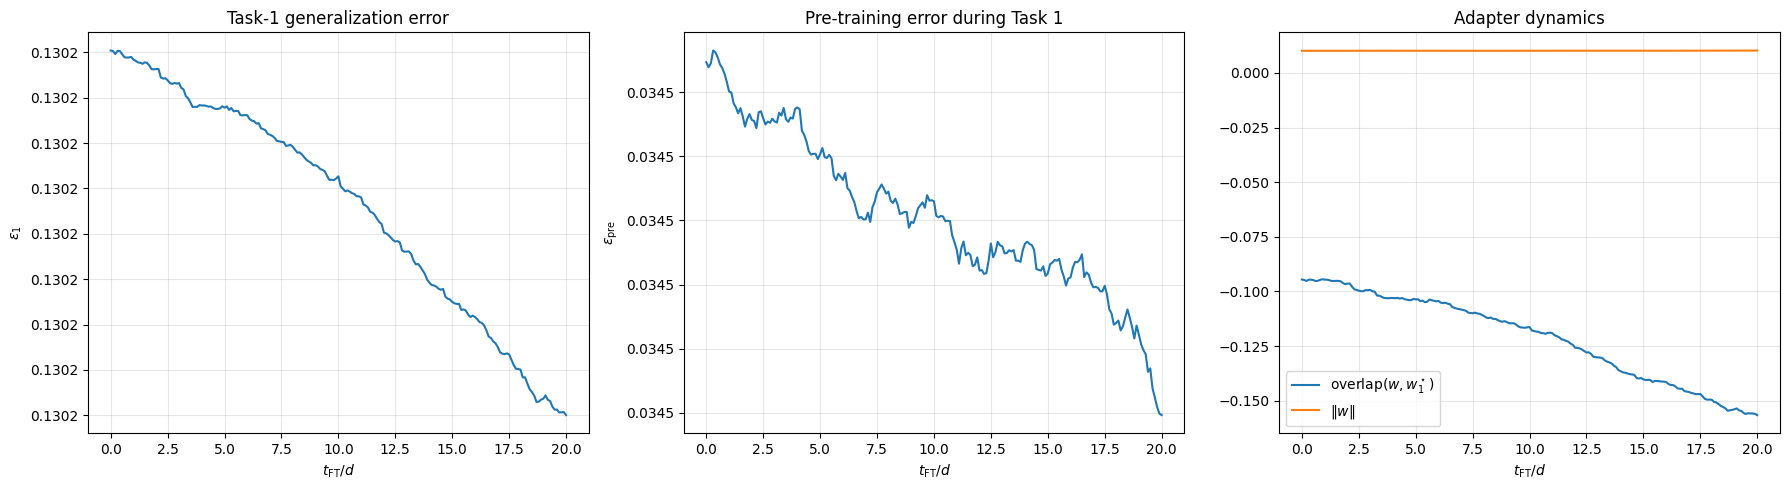

In [57]:
RUN_NAME = "scaling_d100_T5"
PRETRAIN_STEP = 200000

RESULTS_ROOT = (
    REPO_ROOT
    / "results"
    / "task1_finetuning"
)

RUN_DIR = RESULTS_ROOT / RUN_NAME

METRICS_PATH = (
    RUN_DIR
    / f"step_{PRETRAIN_STEP}_task1_metrics.csv"
)


# ============================================================
# Load current metrics
# ============================================================

if not METRICS_PATH.exists():
    raise FileNotFoundError(
        f"No metrics found yet:\n{METRICS_PATH}"
    )

df = pd.read_csv(METRICS_PATH)

df = (
    df
    .sort_values("finetune_step")
    .drop_duplicates(
        subset="finetune_step",
        keep="last",
    )
    .reset_index(drop=True)
)

display(df.tail(10))


# ============================================================
# Current status
# ============================================================

last = df.iloc[-1]

print(
    f"pretraining checkpoint : {PRETRAIN_STEP:,}"
)
print(
    f"finetuning step        : "
    f"{int(last['finetune_step']):,}"
)
print(
    f"t/d                    : "
    f"{last['finetune_step_over_d']:.3f}"
)
print(
    f"Task-1 error           : "
    f"{last['task1_error']:.6e}"
)
print(
    f"Pretraining error      : "
    f"{last['pretraining_error']:.6e}"
)
print(
    f"Overlap with w1*       : "
    f"{last['overlap_w1']:.6f}"
)
print(
    f"||w||                  : "
    f"{last['w_norm']:.6f}"
)


# ============================================================
# Plot
# ============================================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5),
)


# ------------------------------------------------------------
# Task-1 generalization error
# ------------------------------------------------------------

axes[0].plot(
    df["finetune_step_over_d"],
    df["task1_error"],
)

axes[0].set_xlabel(r"$t_{\mathrm{FT}}/d$")
axes[0].set_ylabel(
    r"$\epsilon_1$"
)
axes[0].set_title(
    "Task-1 generalization error"
)
axes[0].grid(True, alpha=0.3)


# ------------------------------------------------------------
# Pretraining error during fine-tuning
# ------------------------------------------------------------

axes[1].plot(
    df["finetune_step_over_d"],
    df["pretraining_error"],
)

axes[1].set_xlabel(r"$t_{\mathrm{FT}}/d$")
axes[1].set_ylabel(
    r"$\epsilon_{\mathrm{pre}}$"
)
axes[1].set_title(
    "Pre-training error during Task 1"
)
axes[1].grid(True, alpha=0.3)


# ------------------------------------------------------------
# Adapter alignment
# ------------------------------------------------------------

axes[2].plot(
    df["finetune_step_over_d"],
    df["overlap_w1"],
    label=r"$\mathrm{overlap}(w,w_1^\star)$",
)

axes[2].plot(
    df["finetune_step_over_d"],
    df["w_norm"],
    label=r"$\|w\|$",
)

axes[2].set_xlabel(r"$t_{\mathrm{FT}}/d$")
axes[2].set_title(
    "Adapter dynamics"
)
axes[2].grid(True, alpha=0.3)
axes[2].legend()

for ax in axes[:2]:
    ax.ticklabel_format(
        axis="y",
        style="plain",
        useOffset=False,
    )

from matplotlib.ticker import FormatStrFormatter

axes[0].yaxis.set_major_formatter(
    FormatStrFormatter("%.4f")
)

axes[1].yaxis.set_major_formatter(
    FormatStrFormatter("%.4f")
)

plt.tight_layout()
plt.show()

In [1]:
RUN_NAME = "scaling_d100_T5"
PRETRAIN_STEP = 250000

RESULTS_ROOT = (
    REPO_ROOT
    / "results"
    / "task1_finetuning"
)

RUN_DIR = RESULTS_ROOT / RUN_NAME

METRICS_PATH = (
    RUN_DIR
    / f"step_{PRETRAIN_STEP}_task1_metrics.csv"
)


# ============================================================
# Load current metrics
# ============================================================

if not METRICS_PATH.exists():
    raise FileNotFoundError(
        f"No metrics found yet:\n{METRICS_PATH}"
    )

df = pd.read_csv(METRICS_PATH)

df = (
    df
    .sort_values("finetune_step")
    .drop_duplicates(
        subset="finetune_step",
        keep="last",
    )
    .reset_index(drop=True)
)

display(df.tail(10))


# ============================================================
# Current status
# ============================================================

last = df.iloc[-1]

print(
    f"pretraining checkpoint : {PRETRAIN_STEP:,}"
)
print(
    f"finetuning step        : "
    f"{int(last['finetune_step']):,}"
)
print(
    f"t/d                    : "
    f"{last['finetune_step_over_d']:.3f}"
)
print(
    f"Task-1 error           : "
    f"{last['task1_error']:.6e}"
)
print(
    f"Pretraining error      : "
    f"{last['pretraining_error']:.6e}"
)
print(
    f"Overlap with w1*       : "
    f"{last['overlap_w1']:.6f}"
)
print(
    f"||w||                  : "
    f"{last['w_norm']:.6f}"
)


# ============================================================
# Plot
# ============================================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(9, 2.5),
)


# ------------------------------------------------------------
# Task-1 generalization error
# ------------------------------------------------------------

axes[0].plot(
    df["finetune_step_over_d"],
    df["task1_error"],
)

axes[0].set_xlabel(r"$t_{\mathrm{FT}}/d$")
axes[0].set_ylabel(
    r"$\epsilon_1$"
)
axes[0].set_title(
    "Task-1 generalization error"
)
axes[0].grid(True, alpha=0.3)


# ------------------------------------------------------------
# Pretraining error during fine-tuning
# ------------------------------------------------------------

axes[1].plot(
    df["finetune_step_over_d"],
    df["pretraining_error"],
)

axes[1].set_xlabel(r"$t_{\mathrm{FT}}/d$")
axes[1].set_ylabel(
    r"$\epsilon_{\mathrm{pre}}$"
)
axes[1].set_title(
    "Pre-training error during Task 1"
)
axes[1].grid(True, alpha=0.3)


# ------------------------------------------------------------
# Adapter alignment
# ------------------------------------------------------------

axes[2].plot(
    df["finetune_step_over_d"],
    df["overlap_w1"],
    label=r"$\mathrm{overlap}(w,w_1^\star)$",
)

axes[2].plot(
    df["finetune_step_over_d"],
    df["w_norm"],
    label=r"$\|w\|$",
)

axes[2].set_xlabel(r"$t_{\mathrm{FT}}/d$")
axes[2].set_title(
    "Adapter dynamics"
)
axes[2].grid(True, alpha=0.3)
axes[2].legend()

for ax in axes[:2]:
    ax.ticklabel_format(
        axis="y",
        style="plain",
        useOffset=False,
    )

from matplotlib.ticker import FormatStrFormatter

axes[0].yaxis.set_major_formatter(
    FormatStrFormatter("%.4f")
)

axes[1].yaxis.set_major_formatter(
    FormatStrFormatter("%.4f")
)

plt.tight_layout()
plt.show()

NameError: name 'REPO_ROOT' is not defined